# Projet COVID 19 : Modelisation Random Forest - 4 classes - Balanced - 3ème itération

## Conditions de modélisation

## Environnement de travail

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    precision_recall_curve,
    average_precision_score
)

from sklearn.inspection import permutation_importance
import joblib

In [2]:
# Répertoire du notebook
NOTEBOOK_DIR = Path.cwd()

# Racine du projet (Liora_Covid)
PROJECT_ROOT = "/../../../enhanced40_features"

# Dossier des CSV
DATA_DIR = PROJECT_ROOT 

print("Notebook :", NOTEBOOK_DIR)
print("Projet   :", PROJECT_ROOT)
print("CSV      :", DATA_DIR)

Notebook : /home/cyril/liora/Liora_Covid/models/random_forest
Projet   : /../../../enhanced40_features
CSV      : /../../../enhanced40_features


In [3]:
# Chargement des données
test=pd.read_csv("../../../enhanced40_features/test_features_top40_anova.csv", sep=",")
validation=pd.read_csv("../../../enhanced40_features/validation_features_top40_anova.csv", sep=",")
train=pd.read_csv("../../../enhanced40_features/train_features_top40_anova.csv", sep=",")

## Définition de la cible et des features

In [4]:
target = "classe"

features = [
    "lum_interieur_masque",
    "lum_exterieur_masque",
    "surface_masque",
    "variance_laplacien"
]

target = "classe"

X_train = train.drop(['filename','classe'], axis = 1)
y_train=train['classe']

X_test = test.drop(['filename','classe'], axis = 1)
y_test = test['classe']

X_val=validation.drop(['filename','classe'], axis = 1)
y_val=validation['classe']


## Vérification des classes

In [5]:
print("Distribution train :")
print(y_train.value_counts(normalize=True))

print("\nDistribution validation :")
print(y_val.value_counts(normalize=True))

print("\nDistribution test :")
print(y_test.value_counts(normalize=True))

Distribution train :
classe
Normal             0.486501
Lung_Opacity       0.287437
COVID              0.161867
Viral Pneumonia    0.064195
Name: proportion, dtype: float64

Distribution validation :
classe
Normal             0.486318
Lung_Opacity       0.287086
COVID              0.162266
Viral Pneumonia    0.064330
Name: proportion, dtype: float64

Distribution test :
classe
Normal             0.486564
Lung_Opacity       0.287428
COVID              0.161708
Viral Pneumonia    0.064299
Name: proportion, dtype: float64


## Pipeline Random Forest

In [6]:
rf_pipe = Pipeline([
    ("model", RandomForestClassifier(
        random_state=0,
        class_weight="balanced",
        n_jobs=-1
    ))
])

## Grille des Hyperparamètres

In [7]:
param_grid_v3 = {
    "model__n_estimators": [200],
    "model__max_depth": [15, 20, 25],
    "model__min_samples_split": [10, 15, 20],
    "model__min_samples_leaf": [2, 3, 4, 5],
    "model__max_features": ["sqrt"]
}

## Cross-validation stratifiée + GridSearch

In [8]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=0
)

grid_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_v3,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...om_state=0))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [15, 20, ...], 'model__max_features': ['sqrt'], 'model__min_samples_leaf': [2, 3, ...], 'model__min_samples_split': [10, 15, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In t

In [9]:
# Meilleurs paramètres

print("Meilleurs paramètres :")
print(grid_rf.best_params_)

print("\nMeilleur score F1 moyen en cross-validation :")
print(grid_rf.best_score_)

Meilleurs paramètres :
{'model__max_depth': 25, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 10, 'model__n_estimators': 200}

Meilleur score F1 moyen en cross-validation :
0.8080690312015536


In [10]:
# Résultats de la GridSearch

results = pd.DataFrame(grid_rf.cv_results_)
results = results.sort_values("rank_test_score")

results[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "params"
]].head(10)

,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,params
24,1,0.808069,0.006795,0.958816,0.000843,"{'model__max_depth': 25, 'model__max_features'..."
27,2,0.808001,0.006102,0.951851,0.001296,"{'model__max_depth': 25, 'model__max_features'..."
15,3,0.807402,0.005552,0.949631,0.001343,"{'model__max_depth': 20, 'model__max_features'..."
25,4,0.806606,0.005393,0.940726,0.000896,"{'model__max_depth': 25, 'model__max_features'..."
12,5,0.806598,0.005657,0.956465,0.000989,"{'model__max_depth': 20, 'model__max_features'..."
33,6,0.806121,0.007052,0.938835,0.000997,"{'model__max_depth': 25, 'model__max_features'..."
0,7,0.806033,0.006374,0.939519,0.001231,"{'model__max_depth': 15, 'model__max_features'..."
13,8,0.805796,0.006230,0.938792,0.001144,"{'model__max_depth': 20, 'model__max_features'..."
18,9,0.805793,0.005632,0.943985,0.001068,"{'model__max_depth': 20, 'model__max_features'..."
3,10,0.805703,0.006034,0.934766,0.001088,"{'model__max_depth': 15, 'model__max_features'..."


## Évaluation sur validation

### Classification report

In [11]:
best_rf = grid_rf.best_estimator_

y_val_pred = best_rf.predict(X_val)
y_val_proba = best_rf.predict_proba(X_val)

print("Évaluation sur le jeu de validation")
print("Accuracy :", accuracy_score(y_val, y_val_pred))
print("Balanced accuracy :", balanced_accuracy_score(y_val, y_val_pred))
print("Precision macro :", precision_score(y_val, y_val_pred, average="macro"))
print("Recall macro :", recall_score(y_val, y_val_pred, average="macro"))
print("F1-score macro :", f1_score(y_val, y_val_pred, average="macro"))
print("F1-score weighted :", f1_score(y_val, y_val_pred, average="weighted"))

print("\nRapport de classification :")
print(classification_report(y_val, y_val_pred))

Évaluation sur le jeu de validation
Accuracy : 0.8026884301488239
Balanced accuracy : 0.8169162312816399
Precision macro : 0.8096669548746456
Recall macro : 0.8169162312816399
F1-score macro : 0.8124189411620801
F1-score weighted : 0.8052651165425969

Rapport de classification :
                 precision    recall  f1-score   support

          COVID       0.58      0.67      0.62       338
   Lung_Opacity       0.78      0.76      0.77       598
         Normal       0.88      0.85      0.86      1013
Viral Pneumonia       1.00      0.99      1.00       134

       accuracy                           0.80      2083
      macro avg       0.81      0.82      0.81      2083
   weighted avg       0.81      0.80      0.81      2083



### Matrice de confusion

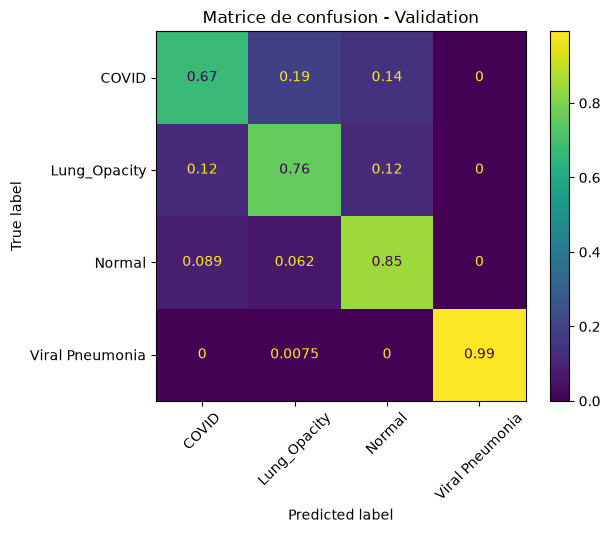

In [12]:
cm = confusion_matrix(y_val, y_val_pred,normalize='true')
class_names = best_rf.named_steps["model"].classes_

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion - Validation")
plt.show()

## Test du modèle

### Classification report

In [13]:
final_model = best_rf

y_test_pred = final_model.predict(X_test)

print("Évaluation finale sur le jeu de test")
print("Accuracy :", accuracy_score(y_test, y_test_pred))
print("Balanced accuracy :", balanced_accuracy_score(y_test, y_test_pred))
print("Precision macro :", precision_score(y_test, y_test_pred, average="macro"))
print("Recall macro :", recall_score(y_test, y_test_pred, average="macro"))
print("F1-score macro :", f1_score(y_test, y_test_pred, average="macro"))
print("F1-score weighted :", f1_score(y_test, y_test_pred, average="weighted"))

print("\nRapport de classification :")
print(classification_report(y_test, y_test_pred))

Évaluation finale sur le jeu de test
Accuracy : 0.8008637236084453
Balanced accuracy : 0.8184356292844596
Precision macro : 0.8093988570138276
Recall macro : 0.8184356292844596
F1-score macro : 0.8128896488516721
F1-score weighted : 0.8034801136606242

Rapport de classification :
                 precision    recall  f1-score   support

          COVID       0.59      0.69      0.64       337
   Lung_Opacity       0.77      0.75      0.76       599
         Normal       0.88      0.84      0.86      1014
Viral Pneumonia       1.00      0.99      1.00       134

       accuracy                           0.80      2084
      macro avg       0.81      0.82      0.81      2084
   weighted avg       0.81      0.80      0.80      2084



### Matrice de confusion

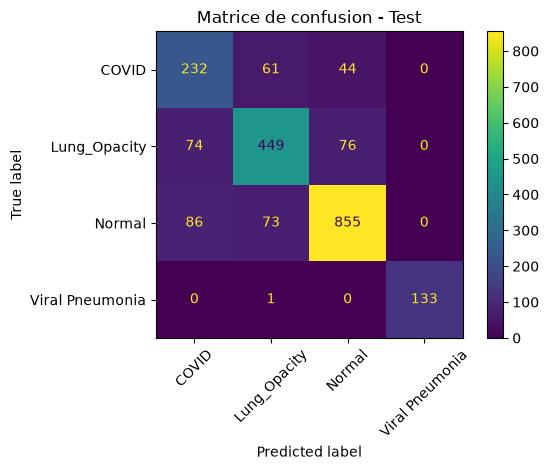

In [ ]:
cm_test = confusion_matrix(y_test, y_test_pred,normalize='true')

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_test,
    display_labels=final_model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion - Test")
plt.tight_layout()
plt.show()

## Courbes Precision / Recall

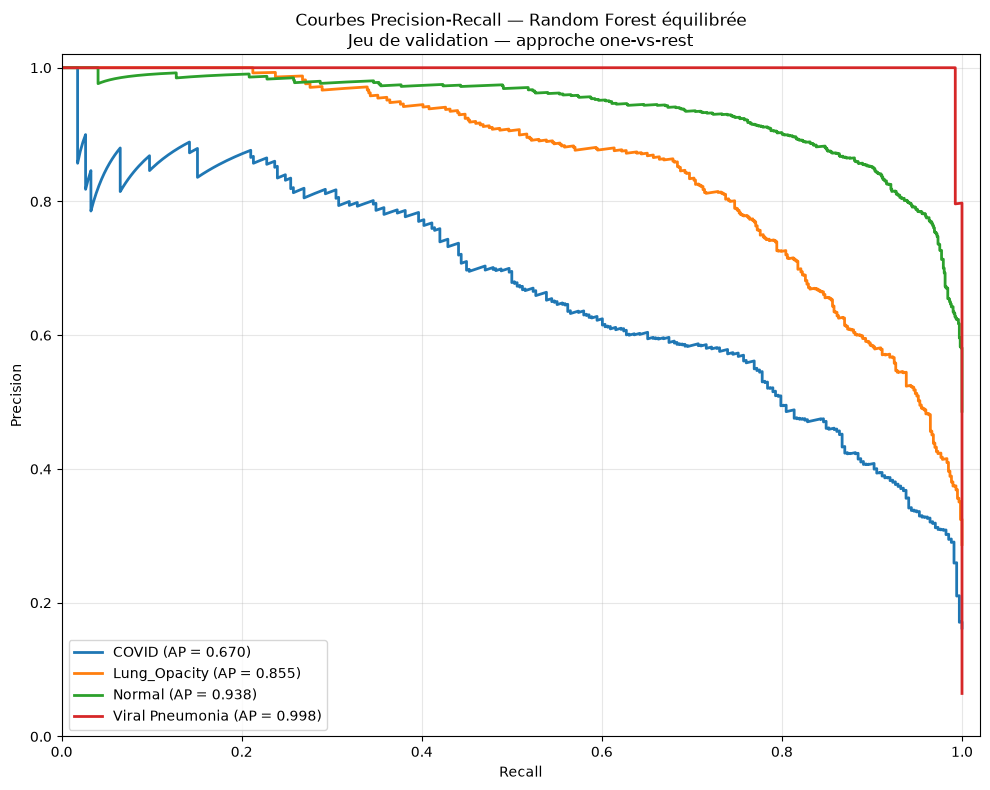

In [15]:
# Courbes Precision / Recall des 4 classes

plt.figure(figsize=(10, 8))

for class_index, class_name in enumerate(class_names):

    # Transformation one-vs-rest :
    # 1 pour la classe étudiée, 0 pour toutes les autres
    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    # Probabilité attribuée à cette classe
    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    average_precision = average_precision_score(
        y_true_binary,
        y_score
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=(
            f"{class_name} "
            f"(AP = {average_precision:.3f})"
        )
    )

plt.title(
    "Courbes Precision-Recall — Random Forest équilibrée\n"
    "Jeu de validation — approche one-vs-rest"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.xlim(0, 1.02)
plt.ylim(0, 1.02)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

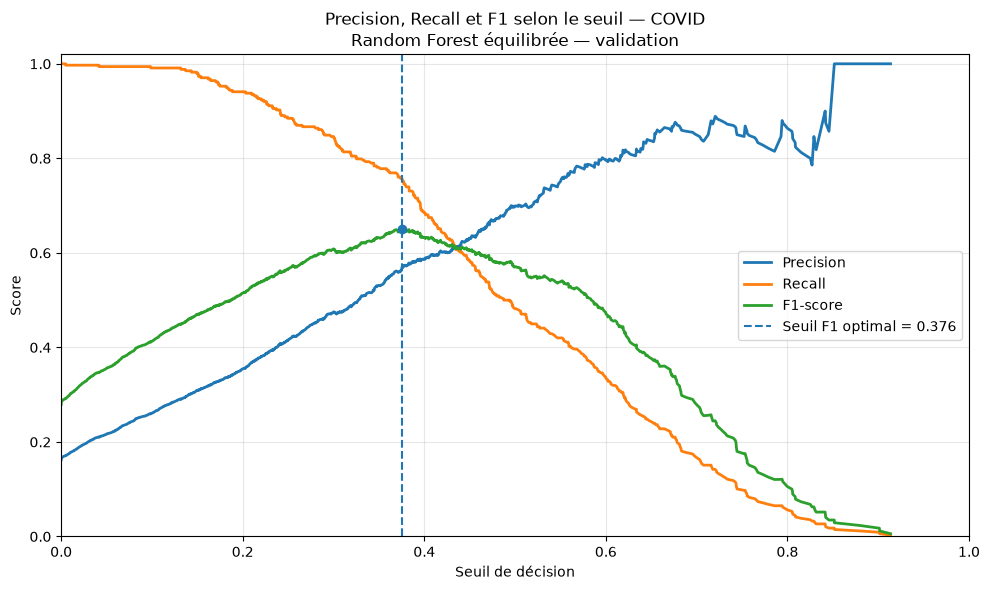

Classe : COVID
Seuil optimal : 0.3755
Precision : 0.5702
Recall : 0.7574
F1-score : 0.6506
--------------------------------------------------


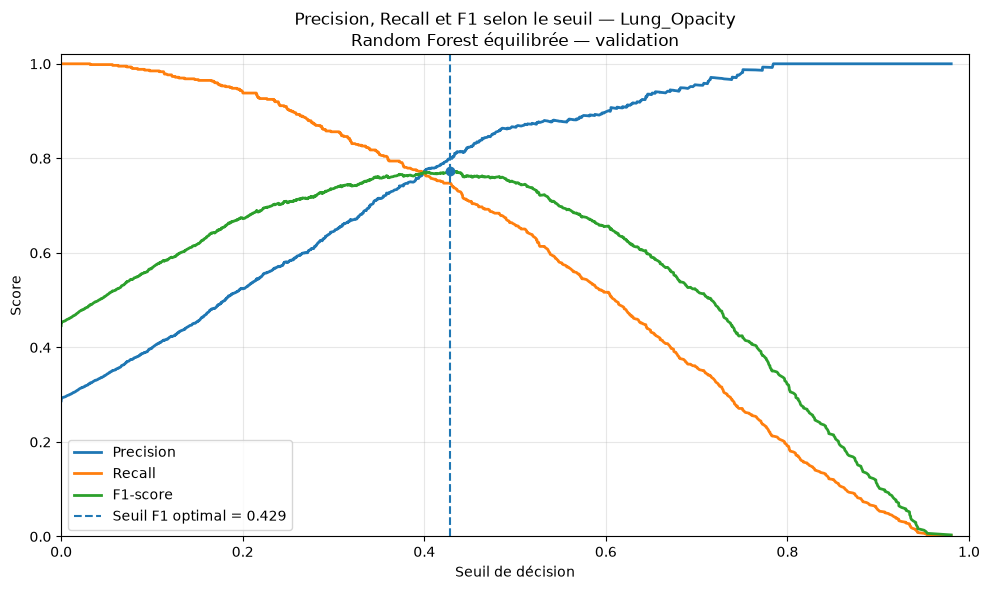

Classe : Lung_Opacity
Seuil optimal : 0.4288
Precision : 0.8011
Recall : 0.7475
F1-score : 0.7734
--------------------------------------------------


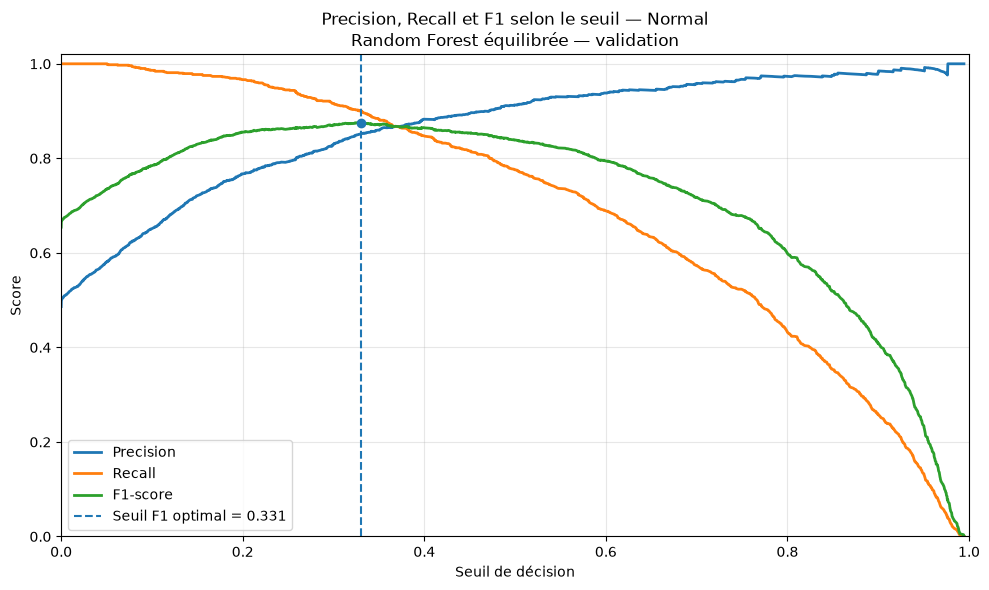

Classe : Normal
Seuil optimal : 0.3307
Precision : 0.8523
Recall : 0.9003
F1-score : 0.8757
--------------------------------------------------


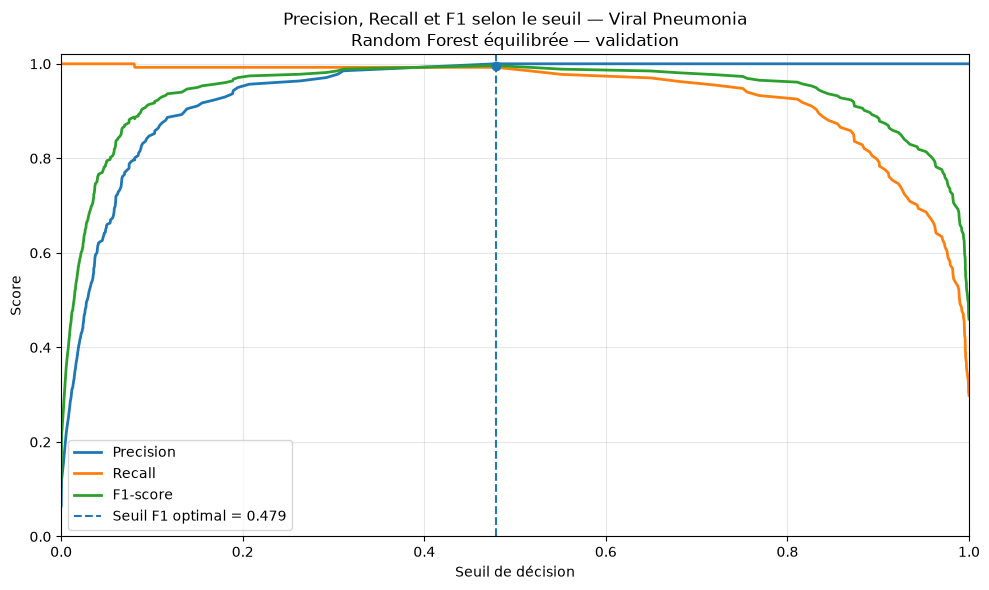

Classe : Viral Pneumonia
Seuil optimal : 0.4786
Precision : 1.0000
Recall : 0.9925
F1-score : 0.9963
--------------------------------------------------


In [16]:
# Precision, Recall et F1 en fonction du seuil

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    # precision et recall contiennent une valeur de plus
    # que thresholds
    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(f1_by_threshold)

    best_threshold = thresholds[best_index]
    best_precision = precision_by_threshold[best_index]
    best_recall = recall_by_threshold[best_index]
    best_f1 = f1_by_threshold[best_index]

    plt.figure(figsize=(10, 6))

    plt.plot(
        thresholds,
        precision_by_threshold,
        label="Precision",
        linewidth=2
    )

    plt.plot(
        thresholds,
        recall_by_threshold,
        label="Recall",
        linewidth=2
    )

    plt.plot(
        thresholds,
        f1_by_threshold,
        label="F1-score",
        linewidth=2
    )

    plt.axvline(
        best_threshold,
        linestyle="--",
        label=(
            f"Seuil F1 optimal = "
            f"{best_threshold:.3f}"
        )
    )

    plt.scatter(
        best_threshold,
        best_f1,
        zorder=5
    )

    plt.title(
        f"Precision, Recall et F1 selon le seuil — {class_name}\n"
        "Random Forest équilibrée — validation"
    )

    plt.xlabel("Seuil de décision")
    plt.ylabel("Score")

    plt.xlim(0, 1)
    plt.ylim(0, 1.02)

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Classe : {class_name}")
    print(f"Seuil optimal : {best_threshold:.4f}")
    print(f"Precision : {best_precision:.4f}")
    print(f"Recall : {best_recall:.4f}")
    print(f"F1-score : {best_f1:.4f}")
    print("-" * 50)

In [17]:
# Récapitulatif des seuils optimaux

threshold_results_rf = []

for class_index, class_name in enumerate(class_names):

    y_true_binary = (
        np.asarray(y_val) == class_name
    ).astype(int)

    y_score = y_val_proba[:, class_index]

    precision, recall, thresholds = precision_recall_curve(
        y_true_binary,
        y_score
    )

    precision_by_threshold = precision[:-1]
    recall_by_threshold = recall[:-1]

    f1_by_threshold = (
        2
        * precision_by_threshold
        * recall_by_threshold
        / (
            precision_by_threshold
            + recall_by_threshold
            + 1e-12
        )
    )

    best_index = np.argmax(f1_by_threshold)

    threshold_results_rf.append({
        "classe": class_name,
        "index_classe": class_index,
        "seuil_optimal_f1": thresholds[best_index],
        "precision_validation": precision_by_threshold[best_index],
        "recall_validation": recall_by_threshold[best_index],
        "f1_validation": f1_by_threshold[best_index],
        "average_precision": average_precision_score(
            y_true_binary,
            y_score
        )
    })

threshold_results_rf_df = pd.DataFrame(
    threshold_results_rf
).round(4)

threshold_results_rf_df

,classe,index_classe,seuil_optimal_f1,precision_validation,recall_validation,f1_validation,average_precision
0,COVID,0,0.3755,0.5702,0.7574,0.6506,0.6695
1,Lung_Opacity,1,0.4288,0.8011,0.7475,0.7734,0.8553
2,Normal,2,0.3307,0.8523,0.9003,0.8757,0.9382
3,Viral Pneumonia,3,0.4786,1.0000,0.9925,0.9963,0.9985
